In [1]:
#importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#import the customer dataset
df=pd.read_csv('customer_sales_dataset.csv')
df.head()

,CustomerID,Name,City,Product,Category,OrderDate,Quantity,Price,PaymentMode
0,101,Alice,Chennai,Laptop,Electronics,2026-01-05,1.0,60000.0,Card
1,102,Bob,Delhi,Mouse,Accessories,2026-01-08,2.0,500.0,UPI
2,103,John,Chennai,Laptop,Electronics,2026-02-11,1.0,62000.0,Card
3,104,David,Mumbai,Keyboard,Accessories,2026-02-14,-2.0,800.0,Cash
4,105,Sara,NaN,Laptop,Electronics,2026-03-03,2.0,61000.0,UPI


In [3]:
df.shape

(1000, 9)

In [4]:
df.describe()

,CustomerID,Quantity,Price
count,1000.000000,934.000000,1000.00000
mean,107.880000,74.864026,24889.24125
std,3.924921,259.358070,28192.17848
min,101.000000,-2.000000,425.15000
25%,104.000000,1.000000,565.61250
50%,108.000000,2.000000,1032.32000
75%,111.000000,3.000000,57266.19000
max,114.000000,1002.000000,70901.23000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CustomerID   1000 non-null   int64  
 1   Name         937 non-null    str    
 2   City         933 non-null    str    
 3   Product      1000 non-null   str    
 4   Category     1000 non-null   str    
 5   OrderDate    1000 non-null   str    
 6   Quantity     934 non-null    float64
 7   Price        1000 non-null   float64
 8   PaymentMode  1000 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 70.4 KB


Name, City,Quantity contains null values
Name and city cannot be predicted hence we shall remove them  while Quantity can be obtained by getting the median

In [6]:
df.isnull().sum()

CustomerID      0
Name           63
City           67
Product         0
Category        0
OrderDate       0
Quantity       66
Price           0
PaymentMode     0
dtype: int64

In [8]:
df.dropna(subset=['Name','City'], inplace=True)

In [9]:
df.isnull().sum()

CustomerID      0
Name            0
City            0
Product         0
Category        0
OrderDate       0
Quantity       66
Price           0
PaymentMode     0
dtype: int64

The null values of name and city are removed while we are going to fill the null with the median of the quantity below

In [10]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [11]:
df.isnull().sum()

CustomerID     0
Name           0
City           0
Product        0
Category       0
OrderDate      0
Quantity       0
Price          0
PaymentMode    0
dtype: int64

The null values are either removed or filled based on their nature

In [12]:
df.shape

(870, 9)

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 870 entries, 0 to 999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CustomerID   870 non-null    int64  
 1   Name         870 non-null    str    
 2   City         870 non-null    str    
 3   Product      870 non-null    str    
 4   Category     870 non-null    str    
 5   OrderDate    870 non-null    str    
 6   Quantity     870 non-null    float64
 7   Price        870 non-null    float64
 8   PaymentMode  870 non-null    str    
dtypes: float64(2), int64(1), str(6)
memory usage: 68.0 KB


In [14]:
df.columns

Index(['CustomerID', 'Name', 'City', 'Product', 'Category', 'OrderDate',
       'Quantity', 'Price', 'PaymentMode'],
      dtype='str')

In [15]:
#Creating a column revenue by using the quantity and price
df['Revenue']= df['Quantity'] * df['Price']

In [16]:
df.columns

Index(['CustomerID', 'Name', 'City', 'Product', 'Category', 'OrderDate',
       'Quantity', 'Price', 'PaymentMode', 'Revenue'],
      dtype='str')

In [17]:
#The min value of quantity is negative which is not possible to be hence we shall remove
df.drop(df[df['Quantity']<0].index,inplace=True)

In [18]:
df.describe()

,CustomerID,Quantity,Price,Revenue
count,869.000000,869.000000,869.000000,869.000000
mean,107.807825,80.303797,22729.087365,73556.907112
std,3.979340,268.100607,28187.837212,131976.851321
min,101.000000,1.000000,425.150000,427.330000
25%,104.000000,1.000000,537.050000,1458.270000
50%,108.000000,2.000000,911.040000,12984.180000
75%,111.000000,3.000000,56425.370000,65672.630000
max,114.000000,1002.000000,70901.230000,573435.990000


In [19]:
df['City'].value_counts()

City
Delhi          273
Chennai        231
Mumbai         219
 Bengaluru      80
chennai         66
Name: count, dtype: int64

In [20]:
df['City']= (df['City'].str.lower()).str.strip()

In [21]:
df['City'].value_counts()

City
chennai      297
delhi        273
mumbai       219
bengaluru     80
Name: count, dtype: int64

In [25]:
#Revenue by category
product_revenue=df.groupby('Product')['Revenue'].sum()
product_revenue

Product
Keyboard      515308.86
Laptop      28100608.83
Monitor      1591859.22
Mouse       33713175.37
Name: Revenue, dtype: float64

In [23]:
#Top 10 customers
top_customer= df.groupby('Name')['Revenue'].sum().sort_values(ascending=False).head(10)
top_customer

Name
Arun     33405287.76
Meena    11731986.07
Anita     6773980.80
John      5102197.55
Alice     4492444.41
Priya     1591859.22
Nisha      250935.36
Rahul      203939.27
Tom        165133.34
Bob         77175.87
Name: Revenue, dtype: float64

In [24]:
#monthly sales statics
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Month']= df['OrderDate'].dt.to_period('M')
monthly_sales= df.groupby('Month')['Revenue'].sum()
monthly_sales

Month
2026-01     4569620.28
2026-02     5162631.78
2026-03     1756992.56
2026-04     7043498.47
2026-05    11731986.07
2026-06    33656223.12
Freq: M, Name: Revenue, dtype: float64

In [26]:
print("Revenue by product : ")
print(product_revenue)
print("Top 10 Customers : ")
print(top_customer)

Revenue by product : 
Product
Keyboard      515308.86
Laptop      28100608.83
Monitor      1591859.22
Mouse       33713175.37
Name: Revenue, dtype: float64
Top 10 Customers : 
Name
Arun     33405287.76
Meena    11731986.07
Anita     6773980.80
John      5102197.55
Alice     4492444.41
Priya     1591859.22
Nisha      250935.36
Rahul      203939.27
Tom        165133.34
Bob         77175.87
Name: Revenue, dtype: float64


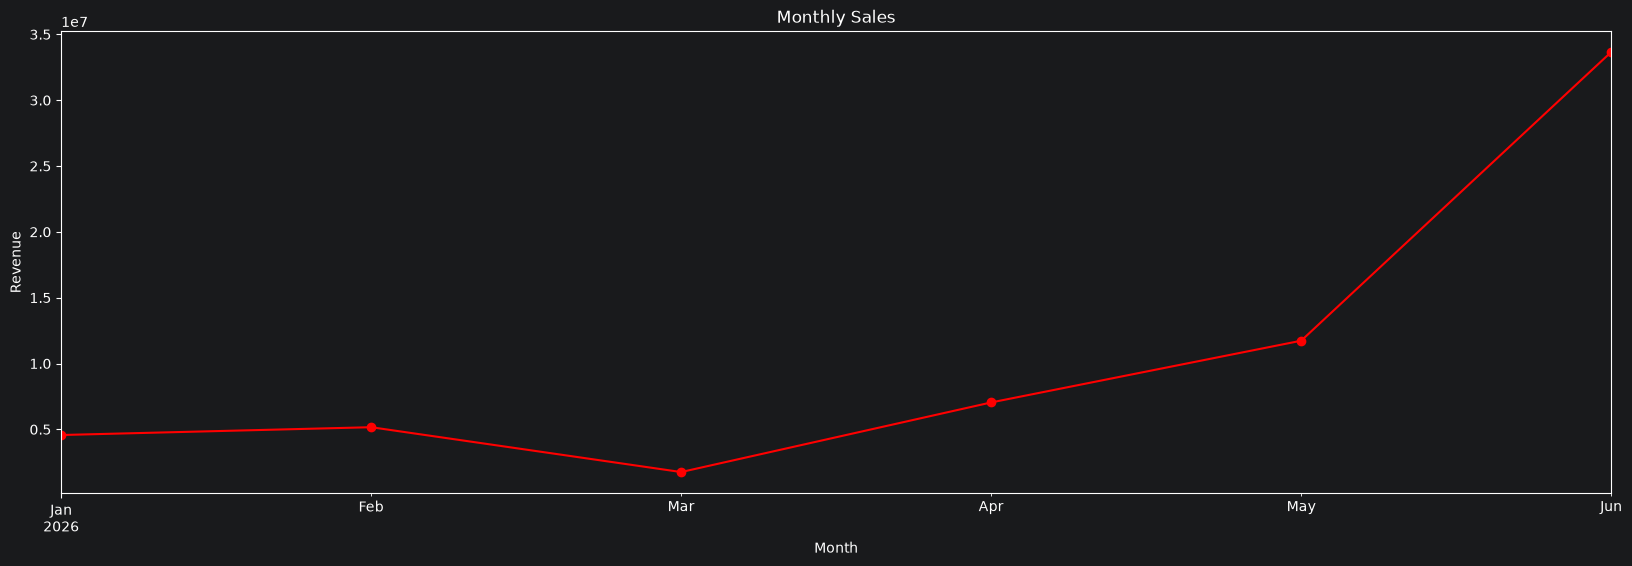

In [27]:
#plot monthly sales
plt.figure(figsize=(20,6))
monthly_sales.plot(marker='o',color='red')
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

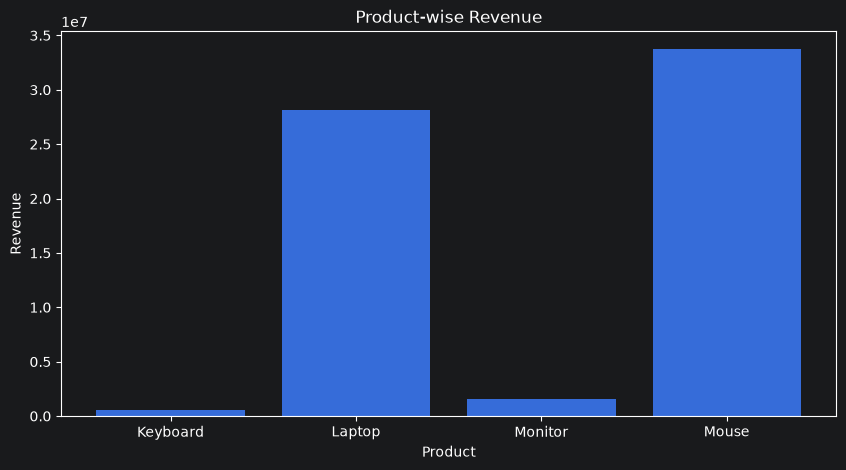

In [28]:
#plotting categorical revenue
plt.figure(figsize=(10,5))
plt.bar(product_revenue.index,product_revenue)
plt.title("Product-wise Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [29]:
df.columns

Index(['CustomerID', 'Name', 'City', 'Product', 'Category', 'OrderDate',
       'Quantity', 'Price', 'PaymentMode', 'Revenue', 'Month'],
      dtype='str')

In [30]:
df.to_csv('Processed_customer_sales_data.csv',index=False)